# Разведывательный анализ датасета резюме

Ноутбук построен по данным из `dataset.xlsx` с учетом описания переменных из `Задание.pdf` и расширенного справочника `regions_extended.csv`.

In [222]:
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    from pypdf import PdfReader
except ModuleNotFoundError:
    project_site_packages = next(Path('.venv/lib').glob('python*/site-packages'), None)
    if project_site_packages is None:
        raise
    sys.path.append(str(project_site_packages))
    from pypdf import PdfReader

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Загрузка данных

In [223]:
df = pd.read_excel("dataset.xlsx")
regions = pd.read_csv("regions_extended.csv", dtype={"code": str})

for col in [
    "date_creation",
    "date_inactivation",
    "date_last_updated",
    "date_modify_inner_info",
    "date_publish",
    "date_time_publish",
]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

pdf_text = "\n".join((page.extract_text() or "") for page in PdfReader("Задание.pdf").pages)

print("dataset shape:", df.shape)
print("regions shape:", regions.shape)
df.head(3)

dataset shape: (49999, 54)
regions shape: (89, 3)


,add_certificates,additional_skills,birthday,birthday_mistake,business_trips,busy_type,country,date_creation,date_inactivation,date_last_updated,date_modify_inner_info,date_publish,date_time_publish,drive_licences,driver_licence_a,driver_licence_b,driver_licence_c,driver_licence_d,driver_licence_e,education_type,experience,experience_mistake,gender,id_candidate,id_cv,id_user_inner_info,inactive,industry_code,inner_info_fullness_rate,inner_info_status,locality,nark_certificate,other_info,position_name,profession_code,region_code,relocation,retraining_capability,salary,schedule_type,schedule_type_1,schedule_type_2,schedule_type_3,schedule_type_4,schedule_type_5,schedule_type_6,skills,time_publish,worldskills_international_name,worldskills_is_international,worldskills_russian_name,worldskills_skill_abbreviation,worldskills_type,worldskills_inspection_status
0,NaN,"Коммуникабельность, дипломатичность, ответстве...",NaN,NaN,0.0,Полная занятость,Российская Федерация,2018-02-12,2019-02-18,2018-10-25,2018-02-12,2018-02-12,2018-02-12 16:48:18,NaN,0,0,0,0,0,NaN,4.0,0,NaN,71a19a60-0fdf-11e8-860a-ef76bd2a03c1,b2ac2f0e-0feb-11e8-860a-ef76bd2a03c1,6c440150-1ea6-11e7-8b66-5d9e90ab9534,1,DeskWork,91,Одобрено,2.300000e+12,NaN,Трудовая деятельность началась с должности сек...,"Делопроизводитель, офис-менеджер, администратор",NaN,2.300000e+12,0.0,1.0,25000,Полный рабочий день,0,0,0,0,1,0,"Офисные программы Li e Office, Word, Excel. 1 ...",16:48:18,NaN,NaN,NaN,NaN,NaN,Не применимо
1,NaN,"Честность, обучаемость, любознательность, акку...",NaN,NaN,0.0,Полная занятость,Российская Федерация,2018-03-29,2019-02-18,2018-12-22,2018-12-19,2018-12-19,2018-12-19 15:38:35,NaN,0,0,0,0,0,NaN,11.0,0,NaN,53ff77c0-a289-11e7-ac45-736ab11edb0c,1d89b050-333b-11e8-b81f-736ab11edb0c,d07779a0-1e61-11e5-8442-1ff705945672,1,DeskWork,92,Одобрено,3.600000e+12,NaN,NaN,Оператор 1с,NaN,3.600000e+12,0.0,1.0,15000,Полный рабочий день,0,0,0,0,1,0,Правильное распределение и хранение документов...,15:38:35,NaN,NaN,NaN,NaN,NaN,Не применимо
2,NaN,"Дисциплинирована, пунктуальна, внимательна, от...",NaN,NaN,0.0,Полная занятость,Российская Федерация,2017-11-20,2019-02-18,2018-01-02,2017-11-21,2017-11-21,2017-11-21 06:49:18,NaN,0,0,0,0,0,NaN,0.0,0,NaN,629bcf80-cde6-11e7-bf93-037acc02728d,06e28f24-cde7-11e7-a533-9122a281f90e,a69177d0-218f-11e6-a9d7-5d9e90ab9534,1,Marketing,76,Одобрено,7.200000e+12,NaN,NaN,"Социолог , маркетолог, аналитик",265312.0,7.200000e+12,0.0,1.0,25000,"Полный рабочий день,Сменный график",0,0,0,0,1,1,Способность использовать знание методов и теор...,06:49:18,NaN,NaN,NaN,NaN,NaN,NaN


In [224]:
regions.head(10)

,code,group,region
0,01,Южные регионы|Сельские регионы,Адыгея
1,02,Промышленные центры|Поволжье|Горнодобывающие,Башкортостан
2,03,Дальний Восток|Горнодобывающие,Бурятия
3,04,Дальний Восток,Алтай
4,05,Южные регионы|Сельские регионы|Северный Кавказ,Дагестан
5,06,Южные регионы|Сельские регионы|Северный Кавказ,Ингушетия
6,07,Южные регионы|Сельские регионы|Северный Кавказ,Кабардино-Балкария
7,08,Южные регионы|Сельские регионы,Калмыкия
8,09,Южные регионы|Сельские регионы|Северный Кавказ,Карачаево-Черкесия
9,10,Промышленные центры|Северо-Запад|Горнодобывающие,Карелия


In [225]:
df.shape

(49999, 54)

## 2. Описание задания

In [226]:
print(pdf_text[:4000])

1 / 4
Введение
Рынок труда в России характеризуется значительной региональной дифференциацией. 
Уровень зарплат, структура занятости, требования к соискателям и предпочтения 
по условиям работы могут сильно различаться в зависимости от региона. Понимание 
этих различий важно как для соискателей, выбирающих место работы и проживания, 
так и для компаний, планирующих расширение в регионы, и для органов власти, 
разрабатывающих политику занятости.
Вам предложен датасет, который содержит информацию о соискателях из разных 
регионов России. Данные включают сведения о желаемой должности, зарплатных 
ожиданиях, опыте работы, образовании, навыках и предпочтениях по графику работы.
Описание данных
Данные содержат информацию о части резюме, размещённых на портале Роструда 
«Работа России».
Описание переменных
Идентификаторы и служебная информация
1. id_candidate — Идентификатор соискателя
2. id_cv — Идентификатор резюме
3. id_user_inner_info — Внутренний идентификатор пользователя сервиса:  
мод

## 3. Базовая структура и качество данных

In [227]:
summary = {
    "shape": df.shape,
    "duplicates_all": int(df.duplicated().sum()),
    "duplicated_id_cv": int(df["id_cv"].duplicated().sum()),
    "duplicated_id_candidate": int(df["id_candidate"].duplicated().sum()),
}
summary

{'shape': (49999, 54),
 'duplicates_all': 0,
 'duplicated_id_cv': 4251,
 'duplicated_id_candidate': 8065}

In [228]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing.head(20).round(2)

worldskills_international_name    99.92
worldskills_skill_abbreviation    99.88
worldskills_russian_name          99.88
worldskills_is_international      99.88
nark_certificate                  99.81
worldskills_type                  99.78
add_certificates                  92.24
other_info                        85.89
education_type                    81.02
birthday                          76.75
birthday_mistake                  75.33
drive_licences                    63.86
profession_code                   52.83
skills                            50.32
additional_skills                 37.22
gender                            29.90
worldskills_inspection_status      9.78
date_inactivation                  8.20
retraining_capability              7.78
relocation                         4.83
dtype: float64

### Пропуски в столбцах с долей выше 30%

Ниже показаны только те столбцы исходного датасета, в которых доля пропусков превышает 30%.

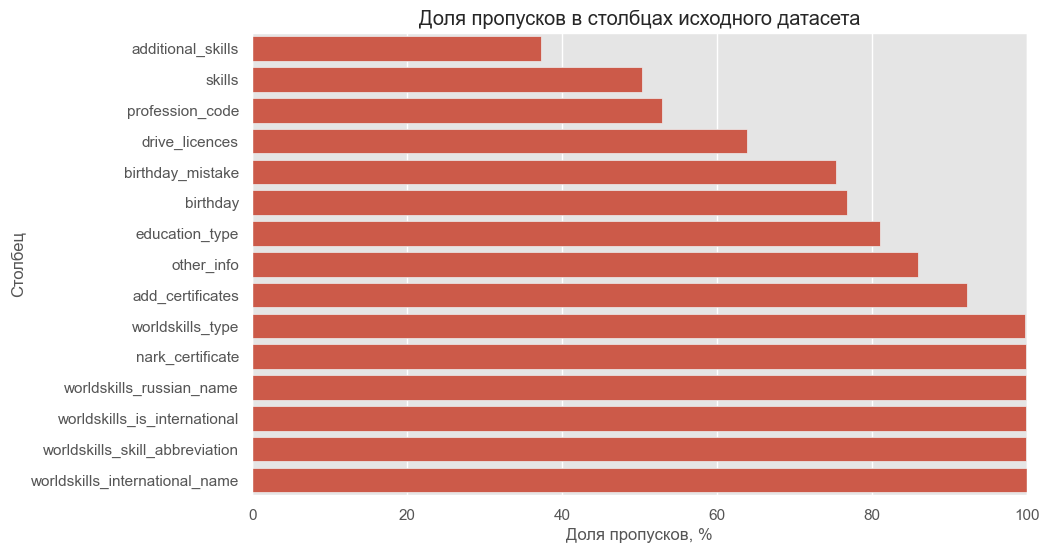

additional_skills                 37.22
skills                            50.32
profession_code                   52.83
drive_licences                    63.86
birthday_mistake                  75.33
birthday                          76.75
education_type                    81.02
other_info                        85.89
add_certificates                  92.24
worldskills_type                  99.78
nark_certificate                  99.81
worldskills_russian_name          99.88
worldskills_is_international      99.88
worldskills_skill_abbreviation    99.88
worldskills_international_name    99.92
dtype: float64

In [283]:
missing_gt_30 = missing[missing > 30].sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.style.use("ggplot")

sns.barplot(x=missing_gt_30.values, y=missing_gt_30.index)
plt.title("Доля пропусков в столбцах исходного датасета")
plt.xlabel("Доля пропусков, %")
plt.ylabel("Столбец")
plt.xlim(0, 100)
plt.show()

missing_gt_30.round(2)

## 4. Подготовка признаков и подключение расширенного справочника регионов

In [230]:
salary = pd.to_numeric(df["salary"], errors="coerce")
experience = pd.to_numeric(df["experience"], errors="coerce")
birthday = pd.to_numeric(df["birthday"], errors="coerce")
fullness = pd.to_numeric(df["inner_info_fullness_rate"], errors="coerce")
region_code = pd.to_numeric(df["region_code"], errors="coerce").astype("Int64")

valid_salary = salary.where((salary > 0) & (salary <= 1_000_000))
valid_experience = experience.where((experience >= 0) & (experience <= 60))
age = (df["date_publish"].dt.year - birthday).where(lambda s: (s >= 14) & (s <= 80))

df["region_prefix"] = region_code.astype("string").str[:2].str.zfill(2)
df = df.merge(regions, left_on="region_prefix", right_on="code", how="left")
df = df.rename(columns={"group": "region_group", "region": "region_name"})

df["region_primary_group"] = df["region_group"].str.split("|").str[0]

region_tags = df[["position_name", "region_name", "region_group", "salary", "experience", "date_publish"]].copy()
region_tags["valid_salary"] = valid_salary
region_tags["valid_experience"] = valid_experience
region_tags["age"] = age
region_tags["region_tag"] = region_tags["region_group"].str.split("|")
region_tags = region_tags.explode("region_tag")
region_tags["region_tag"] = region_tags["region_tag"].str.strip()

df[["region_code", "region_prefix", "region_name", "region_group", "region_primary_group"]].head(10)

,region_code,region_prefix,region_name,region_group,region_primary_group
0,2.300000e+12,23,Краснодарский край,Южные регионы|Сельские регионы|Юг России,Южные регионы
1,3.600000e+12,36,Воронежская область,Центральная Россия|Промышленные центры|Горнодо...,Центральная Россия
2,7.200000e+12,72,Тюменская область,Промышленные центры|Урал|Горнодобывающие,Промышленные центры
3,7.100000e+12,71,Тульская область,Центральная Россия|Промышленные центры,Центральная Россия
4,4.300000e+12,43,Кировская область,Промышленные центры|Поволжье,Промышленные центры
5,5.000000e+12,50,Московская область,Центральная Россия|Промышленные центры,Центральная Россия
6,1.000000e+12,10,Карелия,Промышленные центры|Северо-Запад|Горнодобывающие,Промышленные центры
7,7.200000e+12,72,Тюменская область,Промышленные центры|Урал|Горнодобывающие,Промышленные центры
8,3.600000e+12,36,Воронежская область,Центральная Россия|Промышленные центры|Горнодо...,Центральная Россия
9,5.900000e+12,59,Пермский край,Промышленные центры|Поволжье|Горнодобывающие,Промышленные центры


In [231]:
pd.DataFrame({
    "salary": valid_salary.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]),
    "experience": valid_experience.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]),
    "age": age.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]),
}).round(2)

,salary,experience,age
count,49993.00,49892.00,11623.00
mean,24677.91,5.56,34.91
std,16342.25,7.35,10.17
min,1.00,0.00,14.00
10%,13000.00,0.00,23.00
25%,15000.00,0.00,27.00
50%,20000.00,3.00,33.00
75%,30000.00,8.00,42.00
90%,40000.00,16.00,50.00
95%,50000.00,21.00,54.00


In [232]:
outliers = {
    "salary<=0": int((salary <= 0).fillna(False).sum()),
    "salary<10000": int((salary < 10000).fillna(False).sum()),
    "salary>200000": int((salary > 200000).fillna(False).sum()),
    "salary>500000": int((salary > 500000).fillna(False).sum()),
    "experience>50": int((experience > 50).fillna(False).sum()),
    "experience_mistake=1": int((pd.to_numeric(df["experience_mistake"], errors="coerce") == 1).fillna(False).sum()),
    "birthday_mistake=1": int((pd.to_numeric(df["birthday_mistake"], errors="coerce") == 1).fillna(False).sum()),
}
outliers

{'salary<=0': 6,
 'salary<10000': 1056,
 'salary>200000': 13,
 'salary>500000': 3,
 'experience>50': 13,
 'experience_mistake=1': 4,
 'birthday_mistake=1': 4}

## 5. Категориальные признаки

In [233]:
for col in [
    "gender",
    "education_type",
    "busy_type",
    "business_trips",
    "relocation",
    "retraining_capability",
    "inner_info_status",
    "industry_code",
    "region_primary_group",
]:
    print(f"\n--- {col} ---")
    print(df[col].fillna("<<NA>>").value_counts(dropna=False).head(10))


--- gender ---
gender
Женский    25188
<<NA>>     14951
Мужской     9860
Name: count, dtype: int64

--- education_type ---
education_type
<<NA>>                      40509
Высшее                       4151
Среднее профессиональное     3192
Среднее                      1719
Незаконченное высшее          428
Name: count, dtype: int64

--- busy_type ---
busy_type
Полная занятость       46532
Частичная занятость     2243
Удаленная                714
Временная                321
Сезонная                 109
Стажировка                80
Name: count, dtype: int64

--- business_trips ---
business_trips
0.0       46716
1.0        2847
<<NA>>      436
Name: count, dtype: int64

--- relocation ---
relocation
0.0       47101
<<NA>>     2413
1.0         485
Name: count, dtype: int64

--- retraining_capability ---
retraining_capability
1.0       45788
<<NA>>     3892
0.0         319
Name: count, dtype: int64

--- inner_info_status ---
inner_info_status
Одобрено                 49467
Ожидает подтвер

## 6. Частые должности, регионы и региональные группы

In [234]:
top_positions = df["position_name"].fillna("<<NA>>").value_counts().head(20)
top_regions = df["region_name"].fillna("<<NA>>").value_counts().head(15)
top_primary_groups = df["region_primary_group"].fillna("<<NA>>").value_counts()
top_tags = region_tags["region_tag"].fillna("<<NA>>").value_counts()

display(top_positions)
display(top_regions)
display(top_primary_groups)
display(top_tags)

position_name
Бухгалтер                               2419
Специалист                              2360
Администратор                           1332
Менеджер                                1285
Экономист                               1054
Инженер                                  652
Продавец                                 629
Секретарь                                613
Делопроизводитель                        598
Юрист                                    529
Подсобный рабочий                        456
Водитель                                 432
Охранник                                 393
Повар                                    380
Кладовщик                                372
Оператор пк                              356
Продавец-консультант                     309
Кассир                                   285
Оператор                                 276
Продавец непродовольственных товаров     270
Name: count, dtype: int64

region_name
Москва                                      3351
Московская область                          3070
Краснодарский край                          1781
Санкт-Петербург                             1572
Красноярский край                           1556
Крым                                        1367
Хакасия                                     1215
Ростовская область                          1146
Нижегородская область                       1145
Свердловская область                        1140
Ханты-Мансийский автономный округ — Югра    1137
Челябинская область                         1127
Чеченская Республика                        1076
Самарская область                           1057
Чувашия                                     1040
Name: count, dtype: int64

region_primary_group
Промышленные центры    23674
Центральная Россия     10592
Южные регионы           7776
Столицы                 4923
Дальний Восток          2997
<<NA>>                    37
Name: count, dtype: int64

region_tag
Промышленные центры    34266
Горнодобывающие        22270
Центральная Россия     13943
Сельские регионы        8628
Поволжье                8425
Южные регионы           7776
Сибирь                  5985
Северо-Запад            5767
Урал                    5069
Столицы                 4923
Юг России               4342
Дальний Восток          2997
Северный Кавказ         1919
<<NA>>                    37
Name: count, dtype: int64

## 7. Зарплатные ожидания: ключевые срезы

In [235]:
valid_salary.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2)

count      49993.00
mean       24677.91
std        16342.25
min            1.00
1%          5000.00
25%        15000.00
50%        20000.00
75%        30000.00
90%        40000.00
95%        50000.00
99%        80000.00
max      1000000.00
Name: salary, dtype: float64

In [236]:
salary_by_gender = pd.DataFrame({
    "count": valid_salary.groupby(df["gender"]).size(),
    "median_salary": valid_salary.groupby(df["gender"]).median(),
    "mean_salary": valid_salary.groupby(df["gender"]).mean(),
}).sort_values("median_salary", ascending=False)
salary_by_gender.round(2)

,count,median_salary,mean_salary
gender,,,
Мужской,9860,25000.0,30586.47
Женский,25188,20000.0,23175.73


In [237]:
salary_by_education = pd.DataFrame({
    "count": valid_salary.groupby(df["education_type"]).size(),
    "median_salary": valid_salary.groupby(df["education_type"]).median(),
    "mean_salary": valid_salary.groupby(df["education_type"]).mean(),
}).sort_values(["median_salary", "count"], ascending=[False, False])
salary_by_education.round(2)

,count,median_salary,mean_salary
education_type,,,
Высшее,4151,25000.0,31622.18
Среднее профессиональное,3192,25000.0,25979.17
Незаконченное высшее,428,25000.0,28441.33
Среднее,1719,20000.0,24990.43


In [238]:
salary_by_busy_type = pd.DataFrame({
    "count": valid_salary.groupby(df["busy_type"]).size(),
    "median_salary": valid_salary.groupby(df["busy_type"]).median(),
    "mean_salary": valid_salary.groupby(df["busy_type"]).mean(),
}).sort_values("median_salary", ascending=False)
salary_by_busy_type.round(2)

,count,median_salary,mean_salary
busy_type,,,
Полная занятость,46532,20000.0,24953.80
Удаленная,714,20000.0,23071.98
Частичная занятость,2243,20000.0,20862.75
Сезонная,109,18000.0,20945.10
Временная,321,15000.0,17529.94
Стажировка,80,15000.0,19243.96


In [239]:
salary_by_relocation = pd.DataFrame({
    "count": valid_salary.groupby(df["relocation"]).size(),
    "median_salary": valid_salary.groupby(df["relocation"]).median(),
    "mean_salary": valid_salary.groupby(df["relocation"]).mean(),
}).sort_index()

salary_by_business_trips = pd.DataFrame({
    "count": valid_salary.groupby(df["business_trips"]).size(),
    "median_salary": valid_salary.groupby(df["business_trips"]).median(),
    "mean_salary": valid_salary.groupby(df["business_trips"]).mean(),
}).sort_index()

display(salary_by_relocation.round(2))
display(salary_by_business_trips.round(2))

,count,median_salary,mean_salary
relocation,,,
0.0,47101,20000.0,23870.39
1.0,485,35000.0,41928.20


,count,median_salary,mean_salary
business_trips,,,
0.0,46716,20000.0,23783.17
1.0,2847,30000.0,39148.84


## 8. Зарплата, опыт и возраст

In [240]:
exp_bucket = pd.cut(
    valid_experience,
    bins=[-0.1, 0, 1, 3, 5, 10, 20, 60],
    labels=["0", "1", "2-3", "4-5", "6-10", "11-20", "21+"],
)

salary_by_experience = pd.DataFrame({
    "count": valid_salary.groupby(exp_bucket).size(),
    "median_salary": valid_salary.groupby(exp_bucket).median(),
    "mean_salary": valid_salary.groupby(exp_bucket).mean(),
})
salary_by_experience.round(2)

,count,median_salary,mean_salary
experience,,,
0,16682,20000.0,22196.93
1,4830,20000.0,22350.13
2-3,5878,20000.0,23588.97
4-5,4598,20000.0,24457.15
6-10,8394,25000.0,26188.89
11-20,6742,25000.0,29133.77
21+,2768,25000.0,30747.36


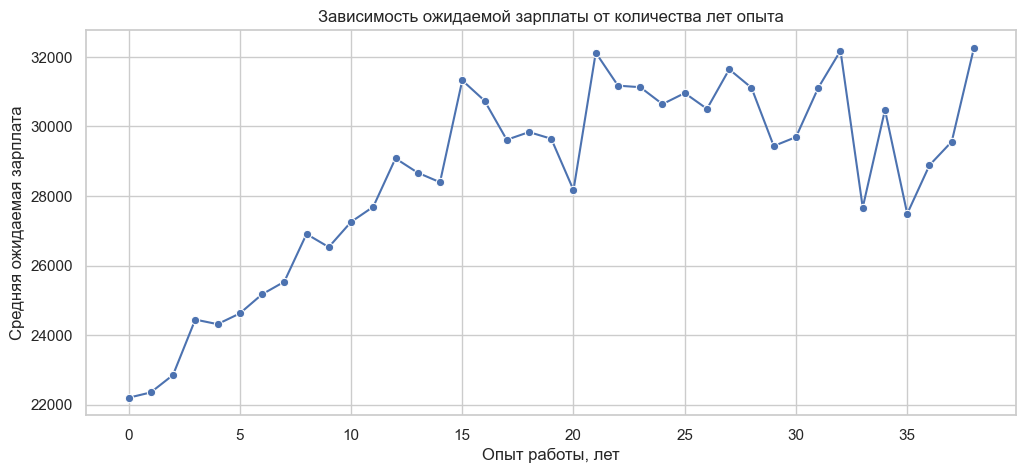

In [241]:
experience_salary_curve = pd.DataFrame({
    "experience": valid_experience,
    "salary": valid_salary,
}).dropna()

experience_salary_curve = experience_salary_curve.groupby("experience").agg(
    mean_salary=("salary", "mean"),
    count=("salary", "size"),
).reset_index()

experience_salary_curve = experience_salary_curve[experience_salary_curve["count"] >= 30]

plt.figure(figsize=(12, 5))
sns.lineplot(data=experience_salary_curve, x="experience", y="mean_salary", marker="o")
plt.title("Зависимость ожидаемой зарплаты от количества лет опыта")
plt.xlabel("Опыт работы, лет")
plt.ylabel("Средняя ожидаемая зарплата")
plt.show()


Text(0.5, 0.98, 'Зависимость ожидаемой зарплаты от опыта по специальностям')

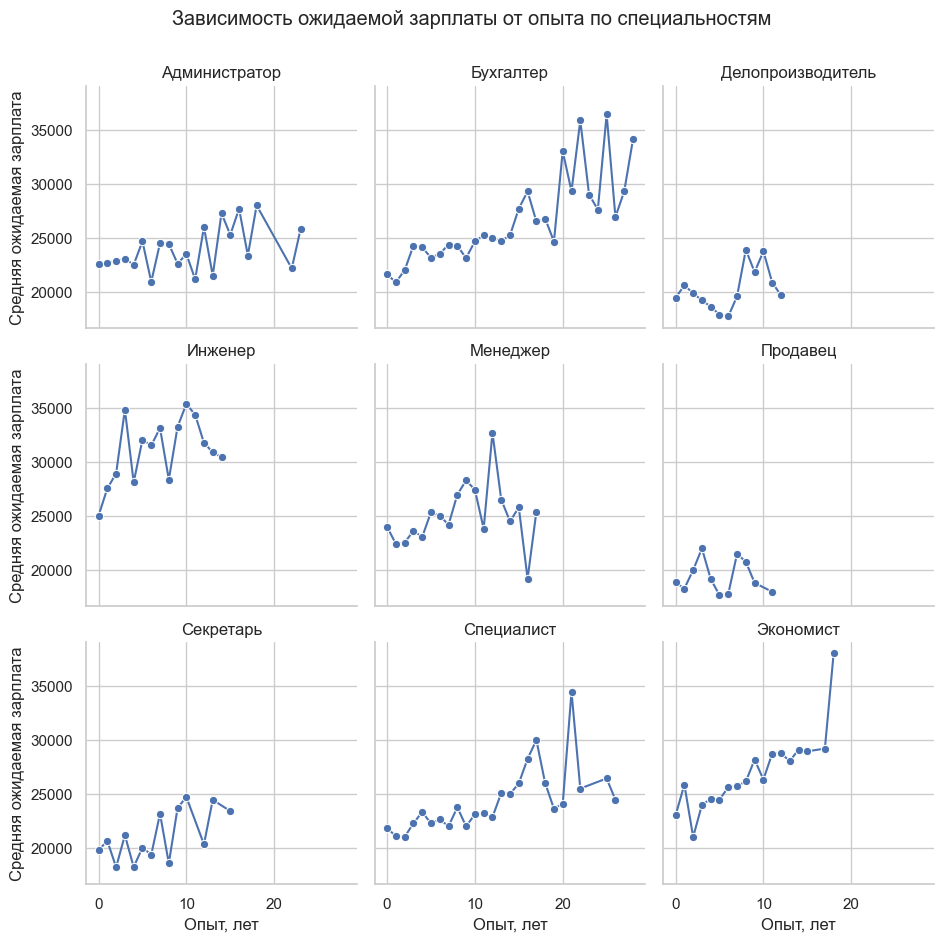

In [242]:
specialty_experience_curve = pd.DataFrame({
    "position_name": df["position_name"],
    "experience": valid_experience,
    "salary": valid_salary,
}).dropna()

top_curve_specialties = specialty_experience_curve["position_name"].value_counts().head(9).index.tolist()
specialty_experience_curve = specialty_experience_curve[specialty_experience_curve["position_name"].isin(top_curve_specialties)]

specialty_experience_curve = specialty_experience_curve.groupby(["position_name", "experience"]).agg(
    mean_salary=("salary", "mean"),
    count=("salary", "size"),
).reset_index()

specialty_experience_curve = specialty_experience_curve[specialty_experience_curve["count"] >= 10]

g = sns.FacetGrid(
    specialty_experience_curve,
    col="position_name",
    col_wrap=3,
    sharex=True,
    sharey=True,
    height=3.2,
)
g.map_dataframe(sns.lineplot, x="experience", y="mean_salary", marker="o")
g.set_axis_labels("Опыт, лет", "Средняя ожидаемая зарплата")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Зависимость ожидаемой зарплаты от опыта по специальностям")


In [243]:
age_bucket = pd.cut(
    age,
    bins=[13, 20, 25, 30, 35, 40, 50, 80],
    labels=["<=20", "21-25", "26-30", "31-35", "36-40", "41-50", "51+"],
)

salary_by_age = pd.DataFrame({
    "count": valid_salary.groupby(age_bucket).size(),
    "median_salary": valid_salary.groupby(age_bucket).median(),
    "mean_salary": valid_salary.groupby(age_bucket).mean(),
})
salary_by_age.round(2)

,count,median_salary,mean_salary
<=20,457,20000.0,21009.65
21-25,1893,20000.0,24042.69
26-30,2103,25000.0,27539.44
31-35,2269,25000.0,30037.98
36-40,1710,30000.0,32561.23
41-50,2095,27000.0,33055.60
51+,1096,25000.0,30787.79


In [244]:
print("salary~experience:", round(valid_salary.corr(valid_experience), 4))
print("salary~age:", round(valid_salary.corr(age), 4))
print("salary~fullness:", round(valid_salary.corr(fullness), 4))

salary~experience: 0.162
salary~age: 0.1495
salary~fullness: 0.0323


## 9. Региональные различия

In [245]:
region_stats = pd.DataFrame({
    "count": valid_salary.groupby(df["region_name"]).size(),
    "median_salary": valid_salary.groupby(df["region_name"]).median(),
    "mean_salary": valid_salary.groupby(df["region_name"]).mean(),
}).dropna()

top_region_stats = region_stats[region_stats["count"] >= 100].sort_values("median_salary", ascending=False).head(15)
bottom_region_stats = region_stats[region_stats["count"] >= 100].sort_values("median_salary", ascending=True).head(15)

display(top_region_stats.round(2))
display(bottom_region_stats.round(2))

,count,median_salary,mean_salary
region_name,,,
Москва,3351,35000.0,40123.49
Камчатский край,141,35000.0,36227.23
Санкт-Петербург,1572,30000.0,32720.12
Ямало-Ненецкий автономный округ,427,30000.0,35325.90
Московская область,3070,30000.0,32167.27
Саха (Якутия),177,30000.0,35577.82
Ханты-Мансийский автономный округ — Югра,1137,30000.0,30496.92
Приморский край,240,25000.0,28102.12
Краснодарский край,1781,25000.0,25115.01


,count,median_salary,mean_salary
region_name,,,
Смоленская область,195,15000.0,19122.62
Оренбургская область,667,15000.0,19453.59
Курганская область,423,15000.0,18132.97
Алтайский край,852,16000.0,19432.55
Орловская область,173,17000.0,18754.34
Удмуртия,431,17000.0,19791.51
Крым,1367,18000.0,20382.61
Псковская область,355,18000.0,20328.63
Саратовская область,557,18000.0,19701.30


In [246]:
primary_group_stats = pd.DataFrame({
    "count": valid_salary.groupby(df["region_primary_group"]).size(),
    "median_salary": valid_salary.groupby(df["region_primary_group"]).median(),
    "mean_salary": valid_salary.groupby(df["region_primary_group"]).mean(),
}).dropna().sort_values("median_salary", ascending=False)

primary_group_stats.round(2)

,count,median_salary,mean_salary
region_primary_group,,,
Столицы,4923,35000.0,37759.46
Дальний Восток,2997,20000.0,24638.77
Промышленные центры,23674,20000.0,22737.11
Центральная Россия,10592,20000.0,24607.07
Южные регионы,7776,20000.0,22415.62


In [247]:
tag_stats = pd.DataFrame({
    "count": region_tags.groupby("region_tag")["valid_salary"].size(),
    "median_salary": region_tags.groupby("region_tag")["valid_salary"].median(),
    "mean_salary": region_tags.groupby("region_tag")["valid_salary"].mean(),
}).dropna().sort_values("median_salary", ascending=False)

tag_stats.round(2)

,count,median_salary,mean_salary
region_tag,,,
Столицы,4923,35000.0,37759.46
Центральная Россия,13943,25000.0,28336.22
Северо-Запад,5767,24000.0,26157.68
Горнодобывающие,22270,20000.0,23071.04
Дальний Восток,2997,20000.0,24638.77
Поволжье,8425,20000.0,20981.18
Промышленные центры,34266,20000.0,23315.22
Северный Кавказ,1919,20000.0,22830.85
Сельские регионы,8628,20000.0,22121.02


In [248]:
exp_bucket_short = pd.cut(valid_experience, bins=[-0.1, 1, 5, 10, 60], labels=["0-1", "2-5", "6-10", "11+"])
primary_group_experience = pd.pivot_table(
    pd.DataFrame({"group": df["region_primary_group"], "exp_bucket": exp_bucket_short, "salary": valid_salary}).dropna(),
    index="group",
    columns="exp_bucket",
    values="salary",
    aggfunc="median",
)
primary_group_experience.round(0)

exp_bucket,0-1,2-5,6-10,11+
group,,,,
Дальний Восток,20000.0,20000.0,25000.0,30000.0
Промышленные центры,20000.0,20000.0,20000.0,25000.0
Столицы,30000.0,35000.0,35000.0,40000.0
Центральная Россия,20000.0,20000.0,23000.0,25000.0
Южные регионы,20000.0,20000.0,20000.0,25000.0


## 10. Отраслевые различия

In [249]:
industry_stats = pd.DataFrame({
    "count": valid_salary.groupby(df["industry_code"]).size(),
    "median_salary": valid_salary.groupby(df["industry_code"]).median(),
    "mean_salary": valid_salary.groupby(df["industry_code"]).mean(),
})

display(industry_stats[industry_stats["count"] >= 100].sort_values("median_salary", ascending=False).head(20).round(2))
display(industry_stats[industry_stats["count"] >= 100].sort_values("median_salary", ascending=True).head(20).round(2))

,count,median_salary,mean_salary
industry_code,,,
Resources,423,35000.0,41424.57
Management,455,30000.0,39978.07
BuldindRealty,1935,30000.0,32762.92
Metallurgy,221,30000.0,30876.81
ElectricpowerIndustry,394,30000.0,30447.66
Transport,1952,27890.0,30900.97
MechanicalEngineering,310,25000.0,28764.71
ChemicalAndFuelIndustry,263,25000.0,30923.05
Marketing,354,25000.0,29707.62


,count,median_salary,mean_salary
industry_code,,,
CareerBegin,135,15000.0,16051.86
NotQualification,2880,15000.0,18149.31
HomePersonal,216,15000.0,18982.20
Agricultural,683,20000.0,24586.60
StateServices,3640,20000.0,24467.02
ServiceMaintenance,929,20000.0,22102.38
Sales,4719,20000.0,23131.11
Safety,1225,20000.0,21666.69
RootLightIndustry,221,20000.0,27613.67


## 11. Массовые позиции

In [250]:
position_stats = pd.DataFrame({
    "count": valid_salary.groupby(df["position_name"]).size(),
    "median_salary": valid_salary.groupby(df["position_name"]).median(),
    "mean_salary": valid_salary.groupby(df["position_name"]).mean(),
})
position_stats[position_stats["count"] >= 50].sort_values("median_salary", ascending=False).head(20).round(2)

,count,median_salary,mean_salary
position_name,,,
Главный бухгалтер,155,40000.0,43096.77
Руководитель,78,40000.0,56169.23
Начальник отдела,55,40000.0,43581.82
Инженер пто,81,30000.0,36666.67
Мастер,95,30000.0,31757.89
Механик,65,30000.0,31707.69
Ведущий специалист,107,30000.0,34158.88
Водитель,432,30000.0,31910.28
Главный специалист,71,30000.0,33140.85


## 12. Распределение специальностей по регионам

In [251]:
top_region_names = df["region_name"].value_counts().head(12).index.tolist()
top_position_names = df["position_name"].value_counts().head(20).index.tolist()

specialty_region = pd.crosstab(df["position_name"].to_numpy(), df["region_name"].to_numpy())
specialty_region_top = specialty_region.reindex(index=top_position_names, columns=top_region_names)
specialty_region_top = specialty_region_top.fillna(0).astype(int)
specialty_region_share = specialty_region_top.div(specialty_region_top.sum(axis=0), axis=1).fillna(0)

display(specialty_region_top)
display((specialty_region_share * 100).round(1))

col_0,Москва,Московская область,Краснодарский край,Санкт-Петербург,Красноярский край,Крым,Хакасия,Ростовская область,Нижегородская область,Свердловская область,Ханты-Мансийский автономный округ — Югра,Челябинская область
row_0,,,,,,,,,,,,
Бухгалтер,95,145,115,63,56,37,52,79,58,52,85,33
Специалист,88,84,119,66,57,26,21,47,65,66,99,57
Администратор,89,91,54,32,59,36,23,36,31,28,31,30
Менеджер,83,91,53,28,59,7,18,25,32,35,27,33
Экономист,51,51,39,33,31,22,33,22,23,17,62,28
Инженер,49,31,28,21,15,4,8,24,17,10,20,17
Продавец,8,21,31,3,23,16,3,17,14,14,5,15
Секретарь,32,36,19,17,18,6,0,22,18,15,32,12
Делопроизводитель,38,25,23,25,15,21,16,4,12,12,44,9


col_0,Москва,Московская область,Краснодарский край,Санкт-Петербург,Красноярский край,Крым,Хакасия,Ростовская область,Нижегородская область,Свердловская область,Ханты-Мансийский автономный округ — Югра,Челябинская область
row_0,,,,,,,,,,,,
Бухгалтер,13.6,14.3,18.9,17.0,12.6,11.8,15.2,22.9,16.3,15.7,18.2,11.1
Специалист,12.6,8.3,19.6,17.8,12.8,8.3,6.2,13.6,18.3,19.9,21.2,19.3
Администратор,12.8,9.0,8.9,8.6,13.2,11.5,6.7,10.4,8.7,8.5,6.6,10.1
Менеджер,11.9,9.0,8.7,7.6,13.2,2.2,5.3,7.2,9.0,10.6,5.8,11.1
Экономист,7.3,5.0,6.4,8.9,7.0,7.0,9.7,6.4,6.5,5.1,13.2,9.5
Инженер,7.0,3.1,4.6,5.7,3.4,1.3,2.3,7.0,4.8,3.0,4.3,5.7
Продавец,1.1,2.1,5.1,0.8,5.2,5.1,0.9,4.9,3.9,4.2,1.1,5.1
Секретарь,4.6,3.5,3.1,4.6,4.0,1.9,0.0,6.4,5.1,4.5,6.8,4.1
Делопроизводитель,5.5,2.5,3.8,6.8,3.4,6.7,4.7,1.2,3.4,3.6,9.4,3.0


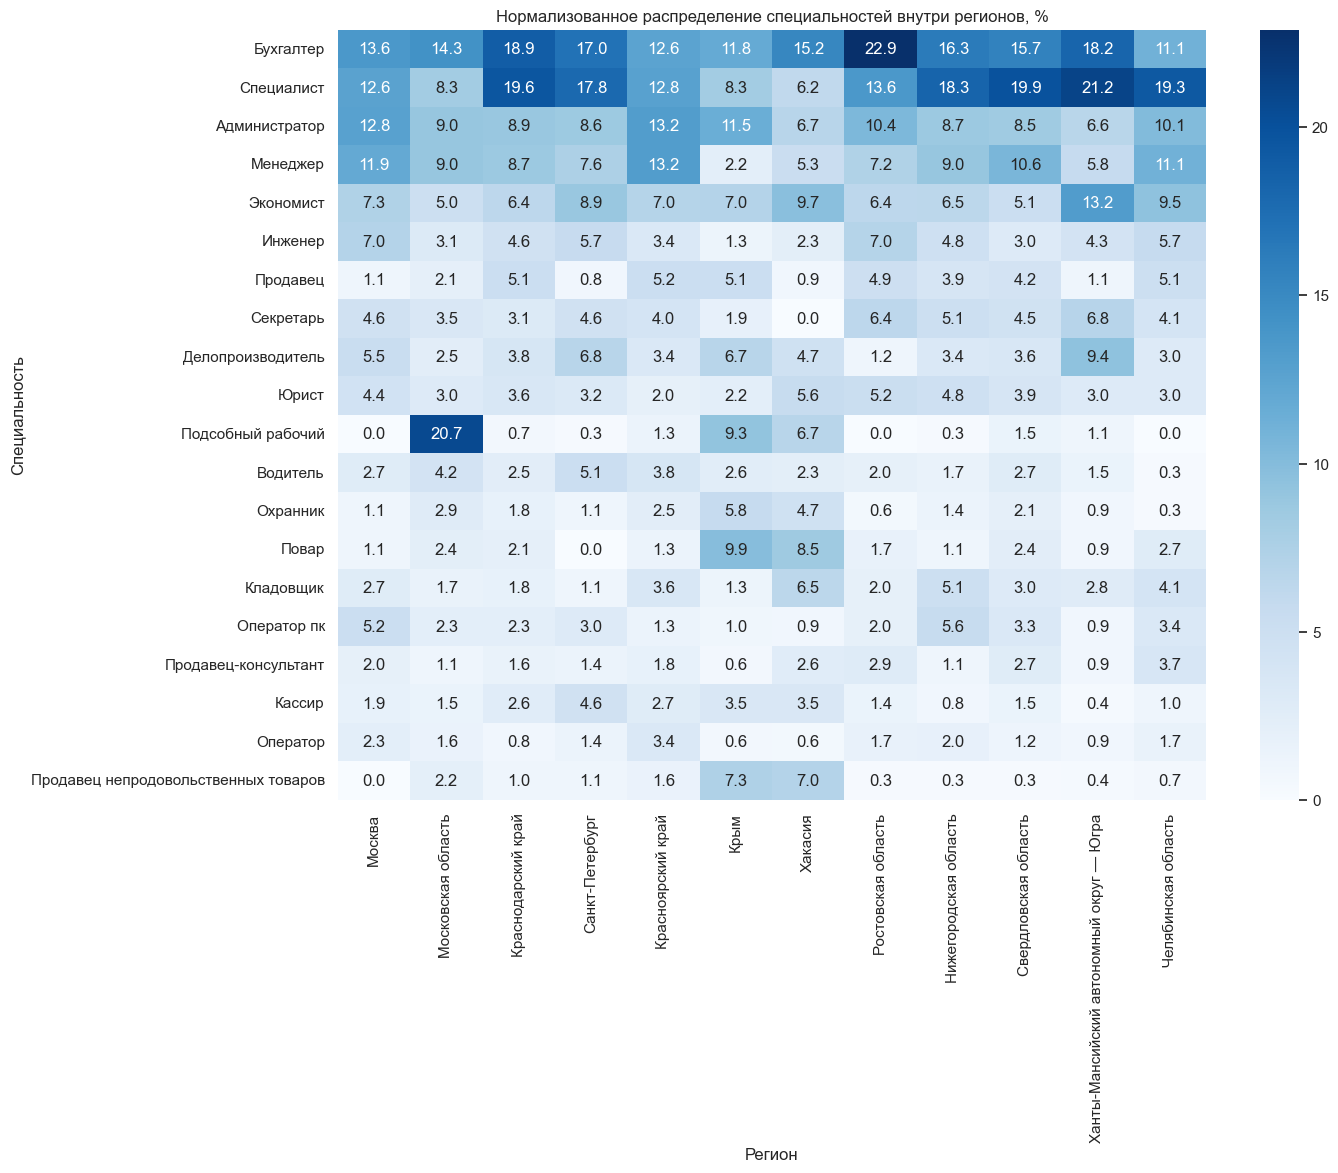

In [252]:
plt.figure(figsize=(14, 10))
sns.heatmap(specialty_region_share * 100, annot=True, fmt=".1f", cmap="Blues")
plt.title("Нормализованное распределение специальностей внутри регионов, %")
plt.xlabel("Регион")
plt.ylabel("Специальность")
plt.show()

In [253]:
top_tags = region_tags["region_tag"].value_counts().head(12).index.tolist()

specialty_tag = (
    region_tags.groupby(["position_name", "region_tag"]).size().unstack(fill_value=0)
)
specialty_tag_top = specialty_tag.reindex(index=top_position_names, columns=top_tags)
specialty_tag_top = specialty_tag_top.fillna(0).astype(int)
specialty_tag_share = specialty_tag_top.div(specialty_tag_top.sum(axis=0), axis=1).fillna(0)

display(specialty_tag_top)
display((specialty_tag_share * 100).round(1))

region_tag,Промышленные центры,Горнодобывающие,Центральная Россия,Сельские регионы,Поволжье,Южные регионы,Сибирь,Северо-Запад,Урал,Столицы,Юг России,Дальний Восток
position_name,,,,,,,,,,,,
Бухгалтер,1700,1145,615,489,409,429,317,271,246,158,278,131
Специалист,1712,1167,512,433,443,378,294,281,336,154,270,113
Администратор,927,576,364,255,214,228,179,158,133,121,124,56
Менеджер,940,597,397,194,208,178,169,144,133,111,121,56
Экономист,725,523,263,175,171,155,137,100,138,84,85,89
Инженер,444,318,167,112,133,99,73,72,69,70,70,39
Продавец,474,319,135,149,137,130,85,72,56,11,69,14
Секретарь,451,292,188,108,102,98,69,66,75,49,56,15
Делопроизводитель,420,315,134,91,97,76,68,97,87,63,38,39


region_tag,Промышленные центры,Горнодобывающие,Центральная Россия,Сельские регионы,Поволжье,Южные регионы,Сибирь,Северо-Запад,Урал,Столицы,Юг России,Дальний Восток
position_name,,,,,,,,,,,,
Бухгалтер,16.0,16.4,15.3,17.9,15.9,17.9,16.8,16.4,15.5,14.8,19.6,15.1
Специалист,16.1,16.7,12.8,15.8,17.2,15.7,15.6,17.0,21.2,14.4,19.1,13.0
Администратор,8.7,8.2,9.1,9.3,8.3,9.5,9.5,9.5,8.4,11.3,8.8,6.4
Менеджер,8.8,8.5,9.9,7.1,8.1,7.4,9.0,8.7,8.4,10.4,8.6,6.4
Экономист,6.8,7.5,6.6,6.4,6.6,6.5,7.3,6.0,8.7,7.9,6.0,10.2
Инженер,4.2,4.5,4.2,4.1,5.2,4.1,3.9,4.3,4.4,6.6,4.9,4.5
Продавец,4.4,4.6,3.4,5.5,5.3,5.4,4.5,4.3,3.5,1.0,4.9,1.6
Секретарь,4.2,4.2,4.7,4.0,4.0,4.1,3.7,4.0,4.7,4.6,4.0,1.7
Делопроизводитель,3.9,4.5,3.3,3.3,3.8,3.2,3.6,5.9,5.5,5.9,2.7,4.5


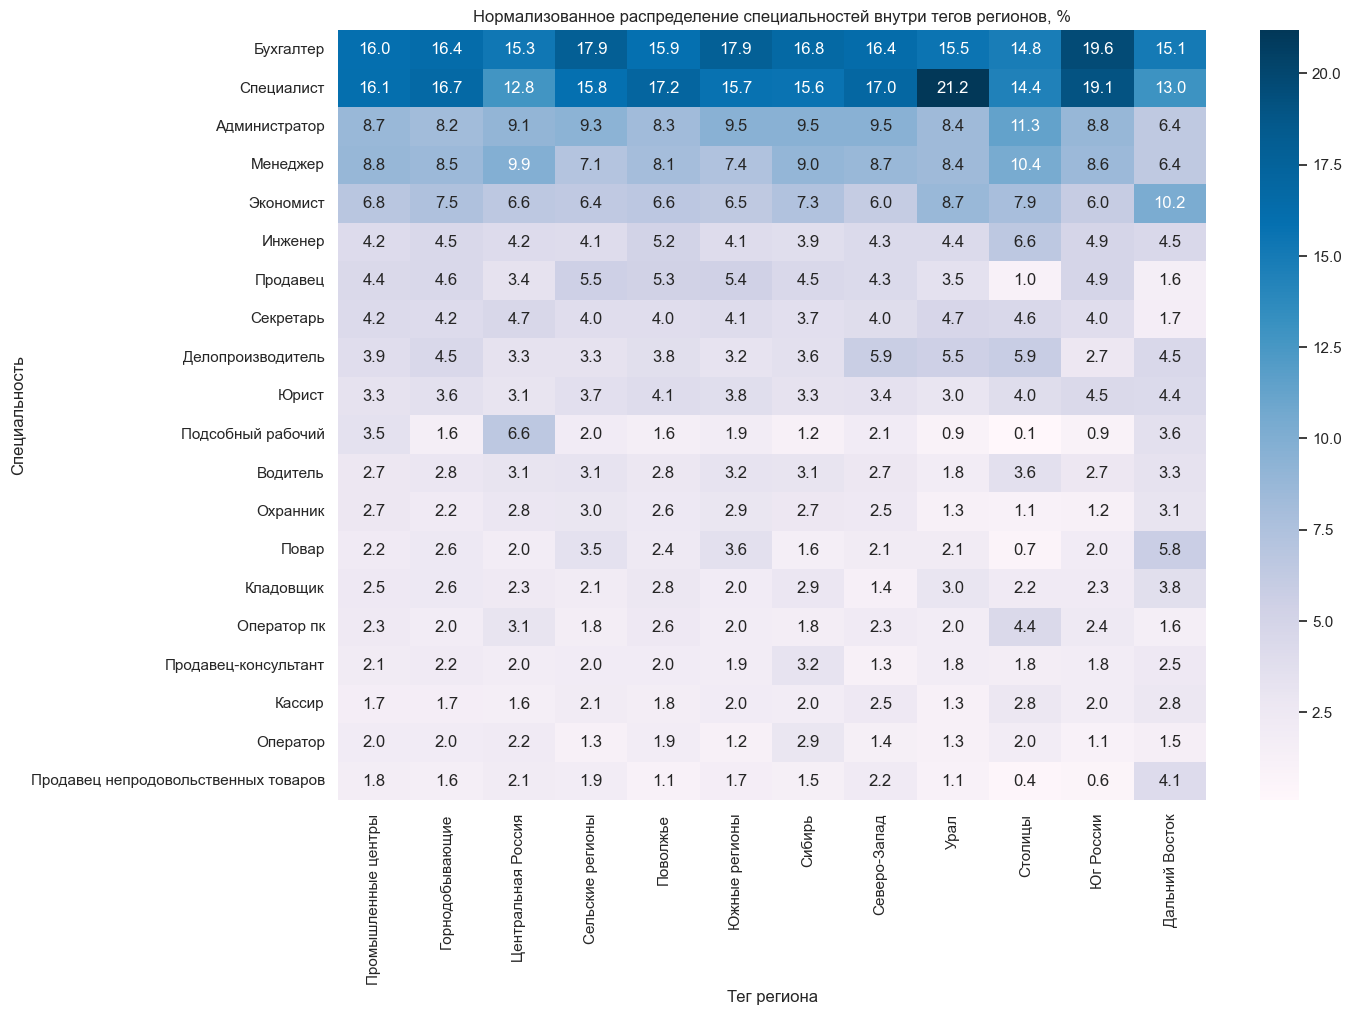

In [254]:
plt.figure(figsize=(14, 10))
sns.heatmap(specialty_tag_share * 100, annot=True, fmt=".1f", cmap="PuBu")
plt.title("Нормализованное распределение специальностей внутри тегов регионов, %")
plt.xlabel("Тег региона")
plt.ylabel("Специальность")
plt.show()

## 13. Графики

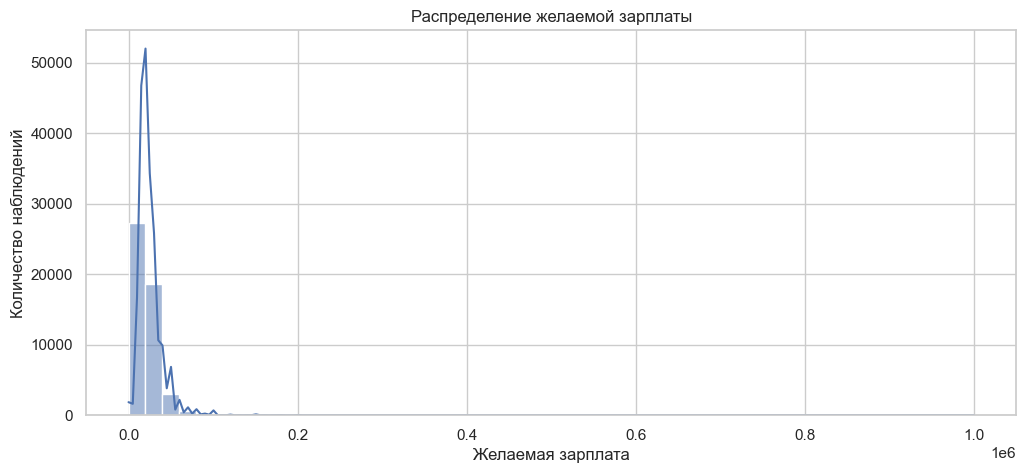

In [255]:
plt.figure(figsize=(12, 5))
sns.histplot(valid_salary.dropna(), bins=50, kde=True)
plt.title("Распределение желаемой зарплаты")
plt.xlabel("Желаемая зарплата")
plt.ylabel("Количество наблюдений")
plt.show()

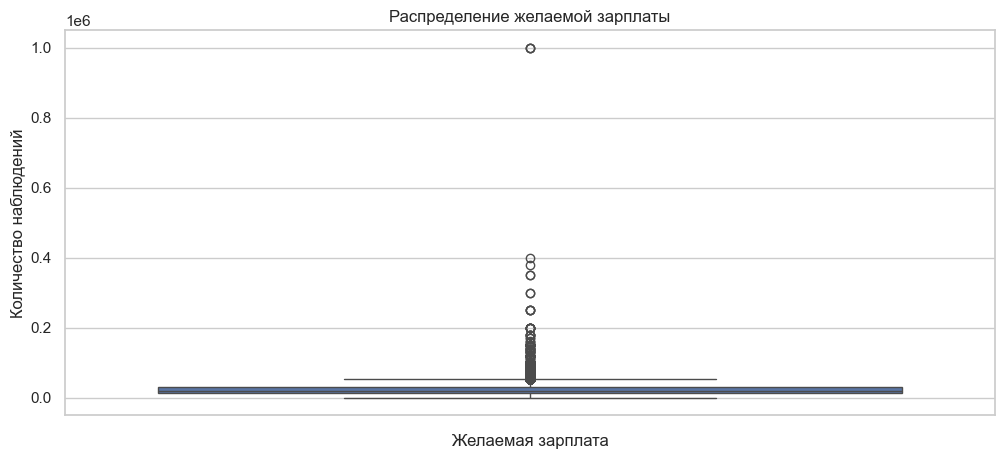

In [256]:
plt.figure(figsize=(12, 5))
sns.boxplot(valid_salary.dropna())
plt.title("Распределение желаемой зарплаты")
plt.xlabel("Желаемая зарплата")
plt.ylabel("Количество наблюдений")
plt.show()

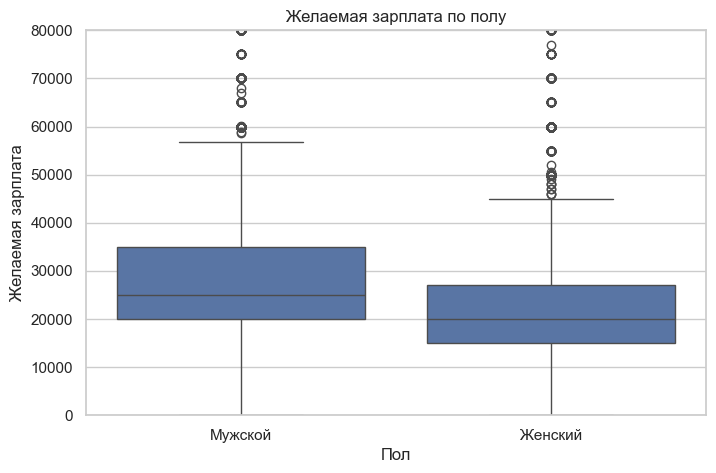

In [257]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df.assign(valid_salary=valid_salary), x="gender", y="valid_salary")
plt.title("Желаемая зарплата по полу")
plt.xlabel("Пол")
plt.ylabel("Желаемая зарплата")
plt.ylim(0, valid_salary.quantile(0.99))
plt.show()

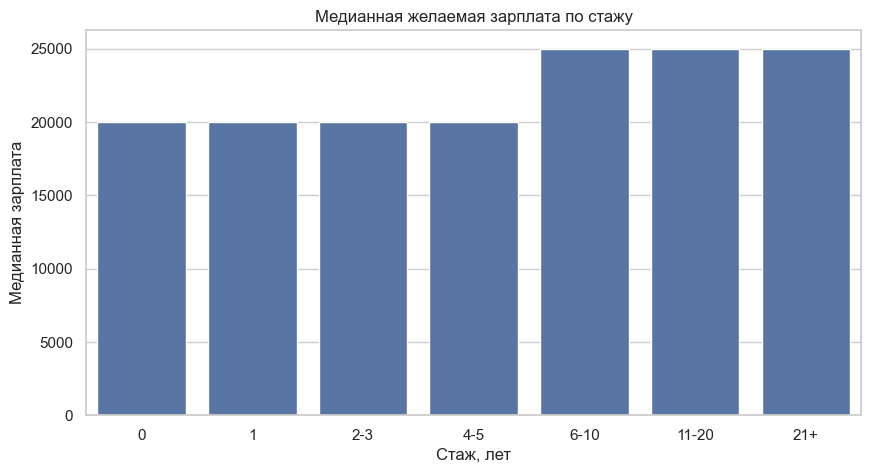

In [258]:
exp_plot = salary_by_experience.reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=exp_plot, x="experience", y="median_salary", color="#4C72B0")
plt.title("Медианная желаемая зарплата по стажу")
plt.xlabel("Стаж, лет")
plt.ylabel("Медианная зарплата")
plt.show()

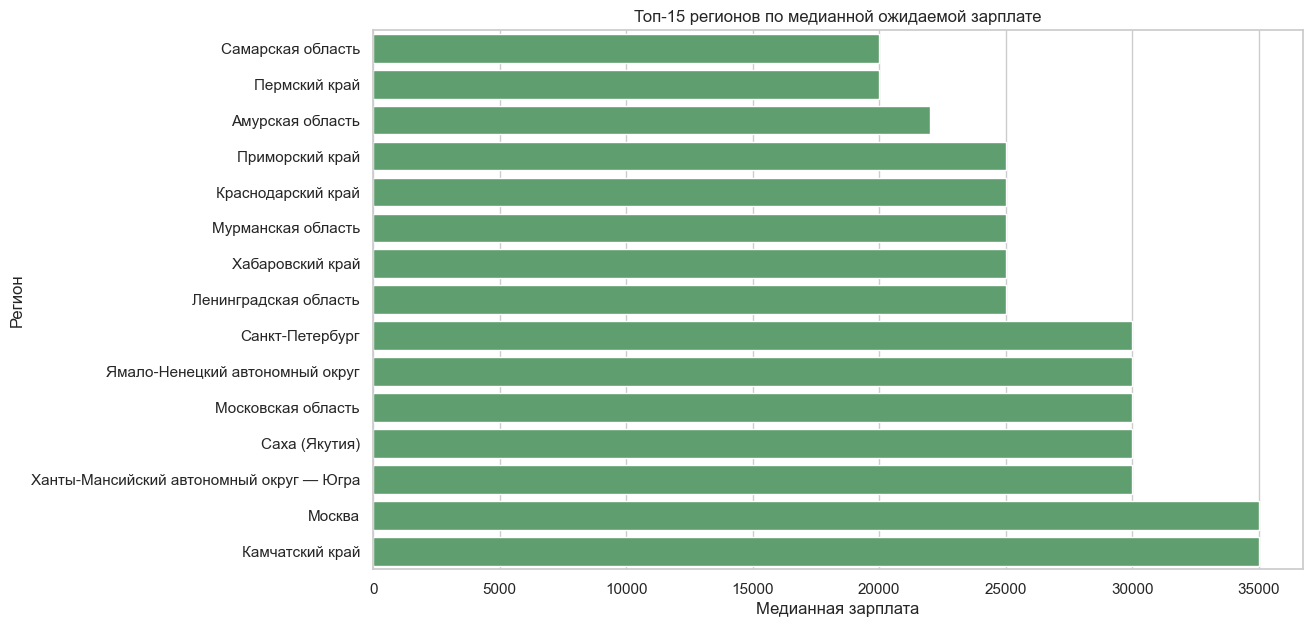

In [259]:
top_regions_plot = top_region_stats.reset_index().sort_values("median_salary", ascending=True)
plt.figure(figsize=(12, 7))
sns.barplot(data=top_regions_plot, x="median_salary", y="region_name", color="#55A868")
plt.title("Топ-15 регионов по медианной ожидаемой зарплате")
plt.xlabel("Медианная зарплата")
plt.ylabel("Регион")
plt.show()

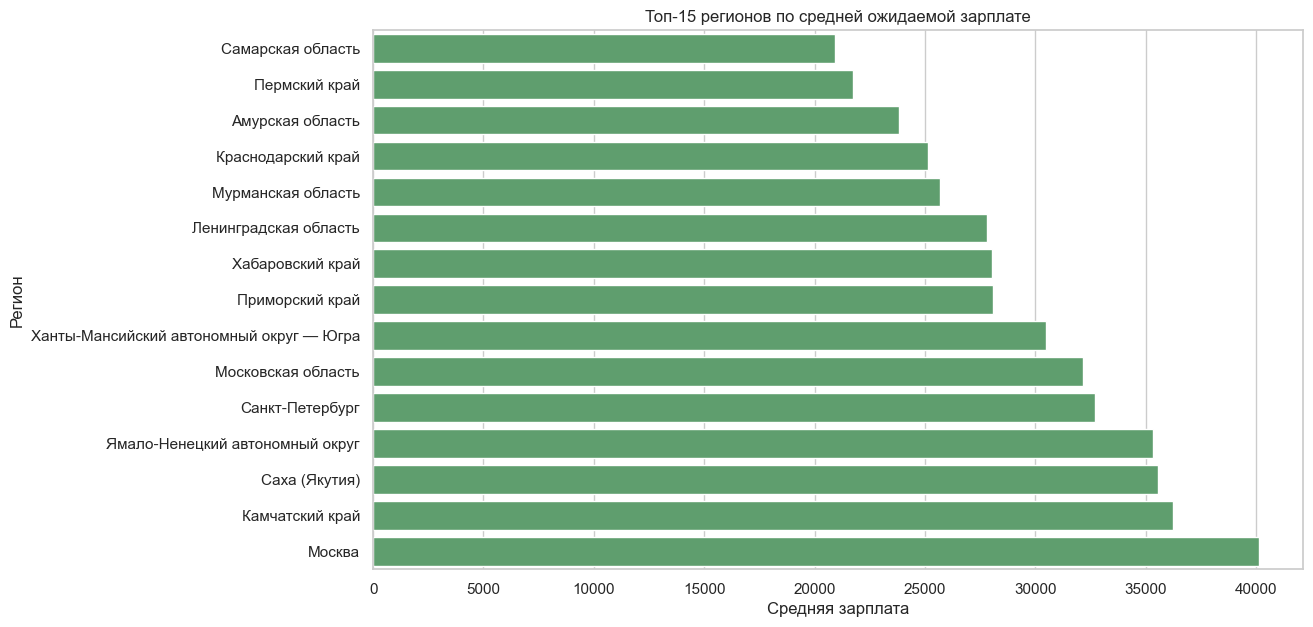

In [260]:
top_regions_plot = top_region_stats.reset_index().sort_values("mean_salary", ascending=True)
plt.figure(figsize=(12, 7))
sns.barplot(data=top_regions_plot, x="mean_salary", y="region_name", color="#55A868")
plt.title("Топ-15 регионов по средней ожидаемой зарплате")
plt.xlabel("Средняя зарплата")
plt.ylabel("Регион")
plt.show()

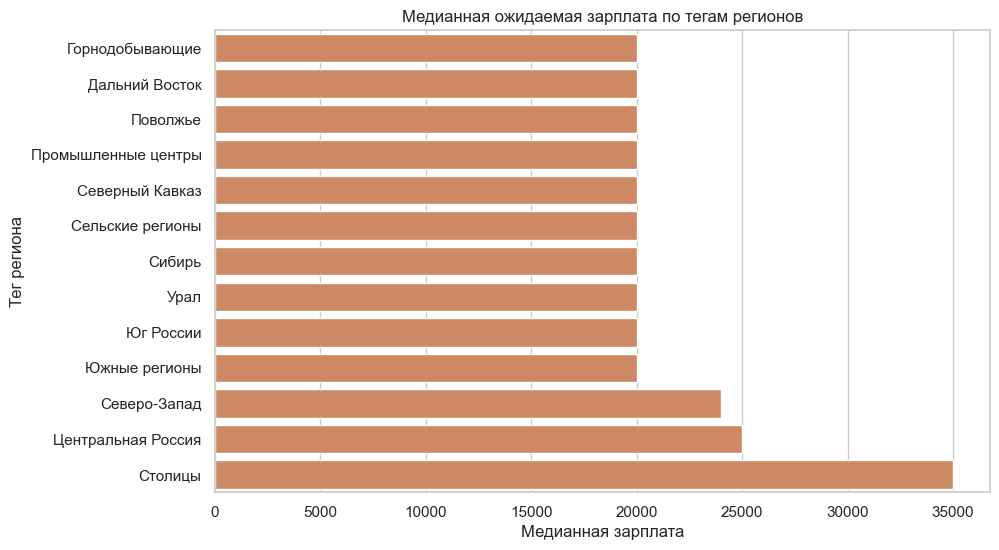

In [261]:
tag_plot = tag_stats.reset_index().sort_values("median_salary", ascending=True)
plt.figure(figsize=(10, 6))
sns.barplot(data=tag_plot, x="median_salary", y="region_tag", color="#DD8452")
plt.title("Медианная ожидаемая зарплата по тегам регионов")
plt.xlabel("Медианная зарплата")
plt.ylabel("Тег региона")
plt.show()

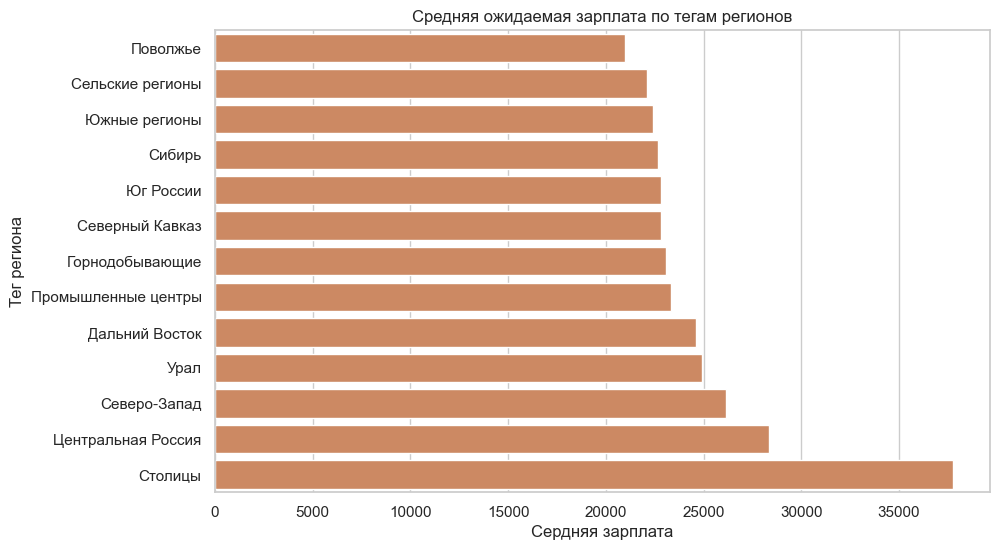

In [262]:
tag_plot = tag_stats.reset_index().sort_values("mean_salary", ascending=True)
plt.figure(figsize=(10, 6))
sns.barplot(data=tag_plot, x="mean_salary", y="region_tag", color="#DD8452")
plt.title("Средняя ожидаемая зарплата по тегам регионов")
plt.xlabel("Сердняя зарплата")
plt.ylabel("Тег региона")
plt.show()

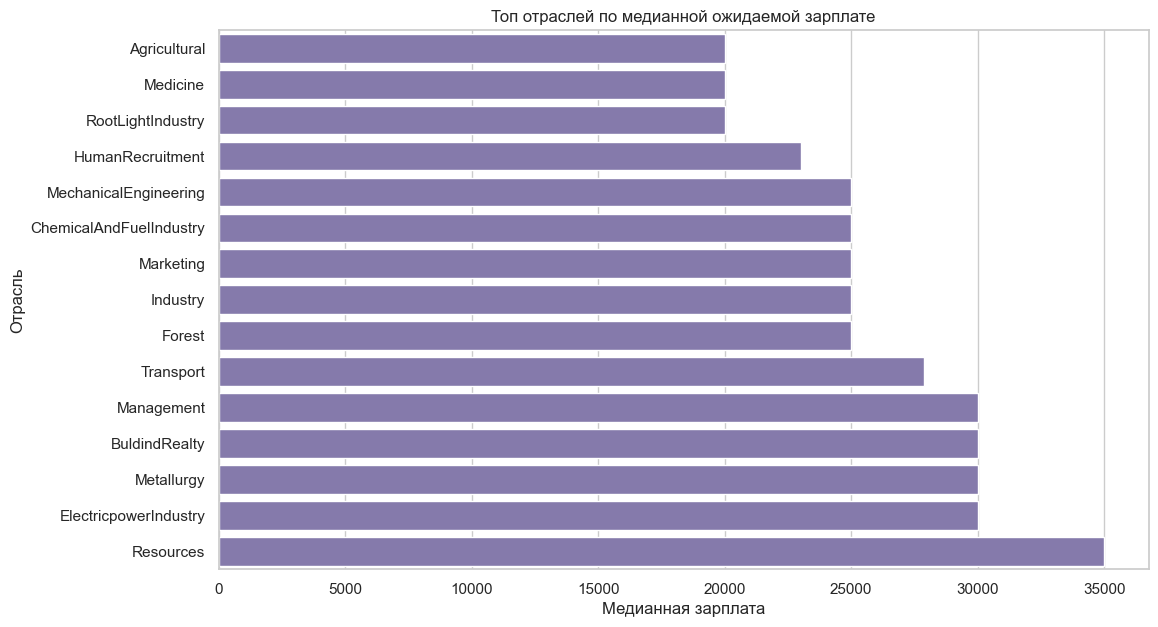

In [263]:
top_industries_plot = industry_stats[industry_stats["count"] >= 100].sort_values("median_salary", ascending=False).head(15).reset_index()
plt.figure(figsize=(12, 7))
sns.barplot(data=top_industries_plot.sort_values("median_salary"), x="median_salary", y="industry_code", color="#8172B3")
plt.title("Топ отраслей по медианной ожидаемой зарплате")
plt.xlabel("Медианная зарплата")
plt.ylabel("Отрасль")
plt.show()

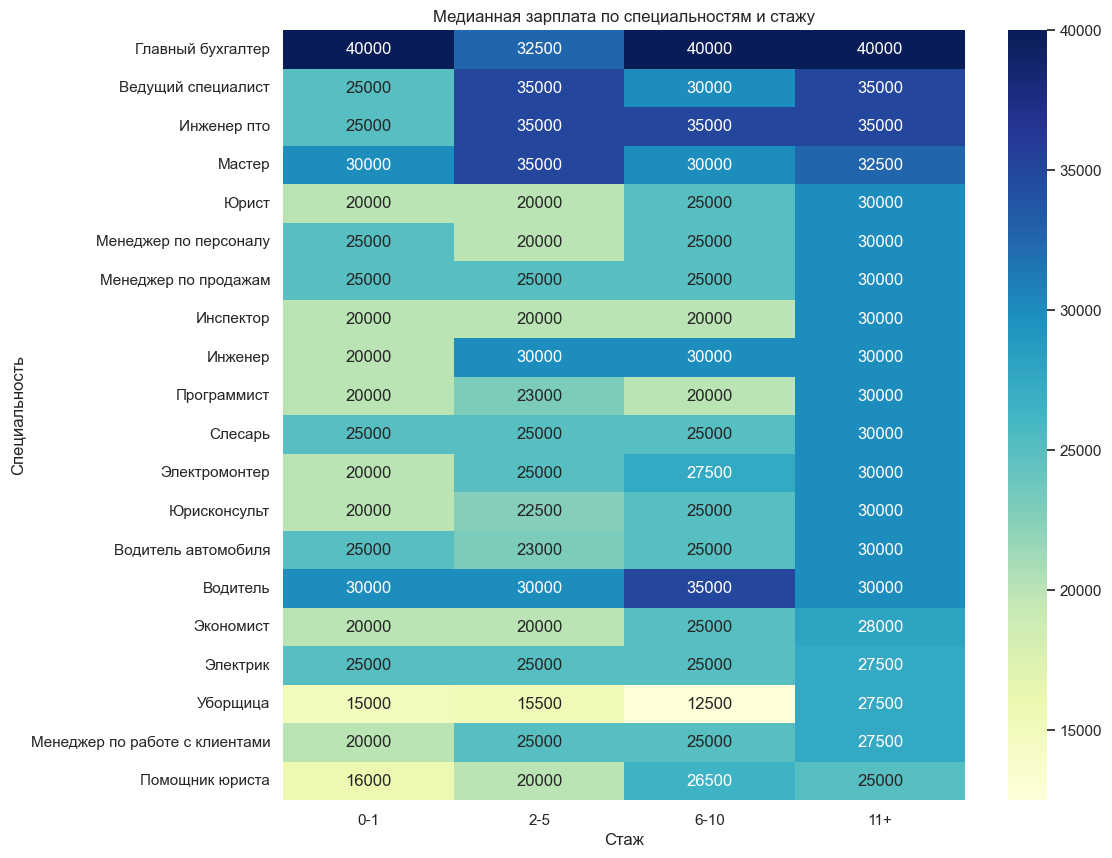

In [264]:
top_specialties = df["position_name"].value_counts()
top_specialties = top_specialties[top_specialties >= 80].index

specialty_experience = pd.pivot_table(
    pd.DataFrame({
        "position_name": df["position_name"],
        "exp_bucket": exp_bucket_short,
        "salary": valid_salary,
    }).dropna(),
    index="position_name",
    columns="exp_bucket",
    values="salary",
    aggfunc="median",
)

specialty_experience = specialty_experience.loc[specialty_experience.index.isin(top_specialties)]
specialty_experience = specialty_experience.sort_values("11+", ascending=False, na_position="last").head(20)

plt.figure(figsize=(11, 10))
sns.heatmap(specialty_experience, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Медианная зарплата по специальностям и стажу")
plt.xlabel("Стаж")
plt.ylabel("Специальность")
plt.show()

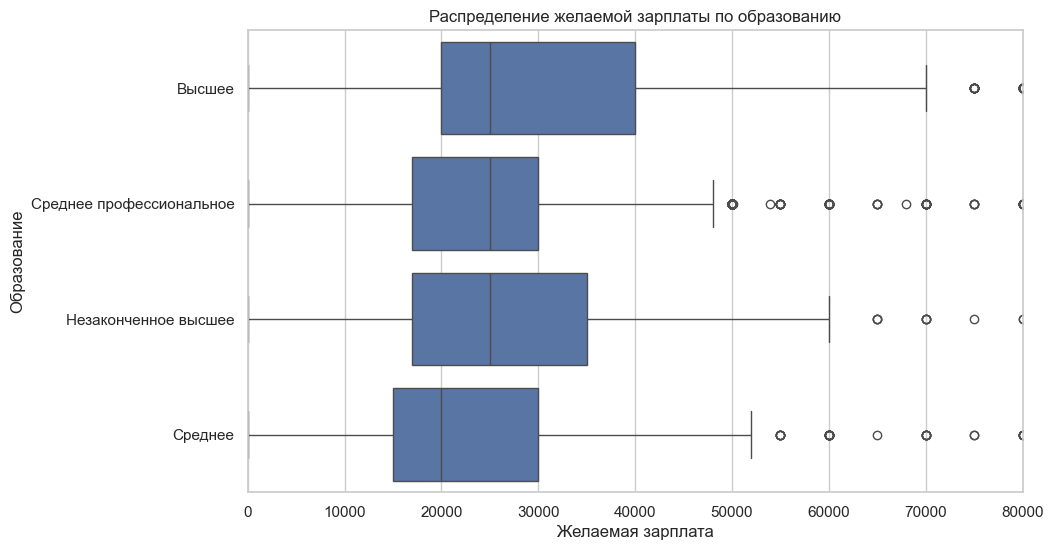

In [265]:
education_boxplot_data = df.assign(valid_salary=valid_salary)
education_boxplot_data = education_boxplot_data[education_boxplot_data["education_type"].notna()].copy()

education_order = salary_by_education.dropna().sort_values(["median_salary", "count"], ascending=[False, False]).index.tolist()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=education_boxplot_data,
    x="valid_salary",
    y="education_type",
    order=education_order,
)
plt.title("Распределение желаемой зарплаты по образованию")
plt.xlabel("Желаемая зарплата")
plt.ylabel("Образование")
plt.xlim(0, valid_salary.quantile(0.99))
plt.show()

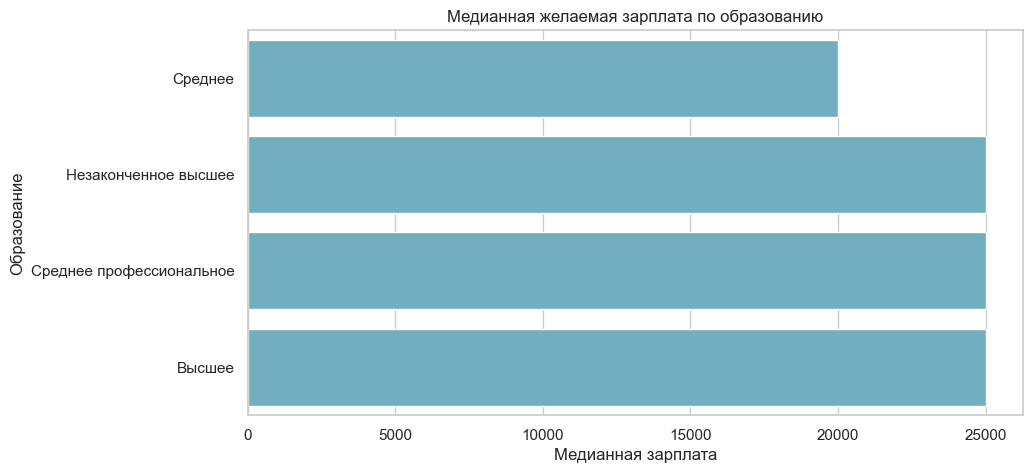

In [266]:
education_plot = salary_by_education.reset_index().dropna(subset=["education_type"])
education_plot = education_plot.sort_values(["median_salary", "count"], ascending=[True, True])

plt.figure(figsize=(10, 5))
sns.barplot(data=education_plot, x="median_salary", y="education_type", color="#64B5CD")
plt.title("Медианная желаемая зарплата по образованию")
plt.xlabel("Медианная зарплата")
plt.ylabel("Образование")
plt.show()

## 14. Распределение по времени

In [267]:
time_df = df.copy()
time_df["publish_date"] = pd.to_datetime(time_df["date_publish"], errors="coerce")
time_df["publish_month"] = time_df["publish_date"].dt.to_period("M").astype("string")
time_df["publish_weekday"] = time_df["publish_date"].dt.day_name()
time_df["publish_hour"] = pd.to_datetime(time_df["time_publish"], errors="coerce").dt.hour

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
]

display(time_df["publish_date"].describe())
display(time_df["publish_month"].value_counts().sort_index())
display(time_df["publish_weekday"].value_counts().reindex(weekday_order))
display(time_df["publish_hour"].value_counts().sort_index())

count                         49999
mean     2018-06-26 03:31:23.773675
min             2015-06-17 00:00:00
25%             2017-09-27 00:00:00
50%             2018-08-10 00:00:00
75%             2019-02-01 00:00:00
max             2021-11-12 00:00:00
Name: publish_date, dtype: object

publish_month
2015-06     1
2015-07    11
2015-08    18
2015-09    32
2015-10    28
           ..
2021-07    51
2021-08    30
2021-09    47
2021-10    16
2021-11    17
Name: count, Length: 78, dtype: Int64

publish_weekday
Monday       12155
Tuesday       9341
Wednesday     8953
Thursday      8793
Friday        7604
Saturday      1472
Sunday        1681
Name: count, dtype: int64

Series([], Name: count, dtype: int64)

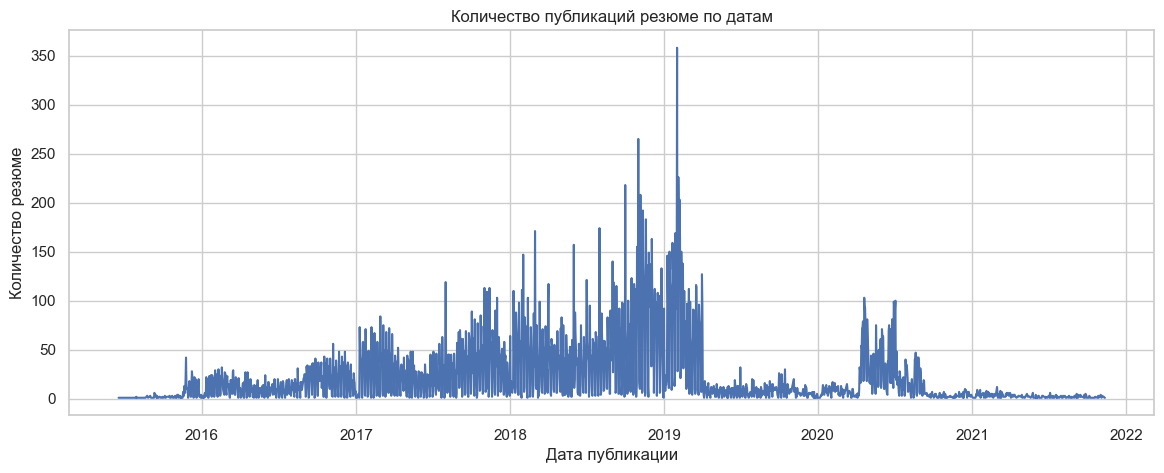

In [268]:
daily_counts = time_df.groupby("publish_date").size().reset_index(name="count")
plt.figure(figsize=(14, 5))
sns.lineplot(data=daily_counts, x="publish_date", y="count")
plt.title("Количество публикаций резюме по датам")
plt.xlabel("Дата публикации")
plt.ylabel("Количество резюме")
plt.show()

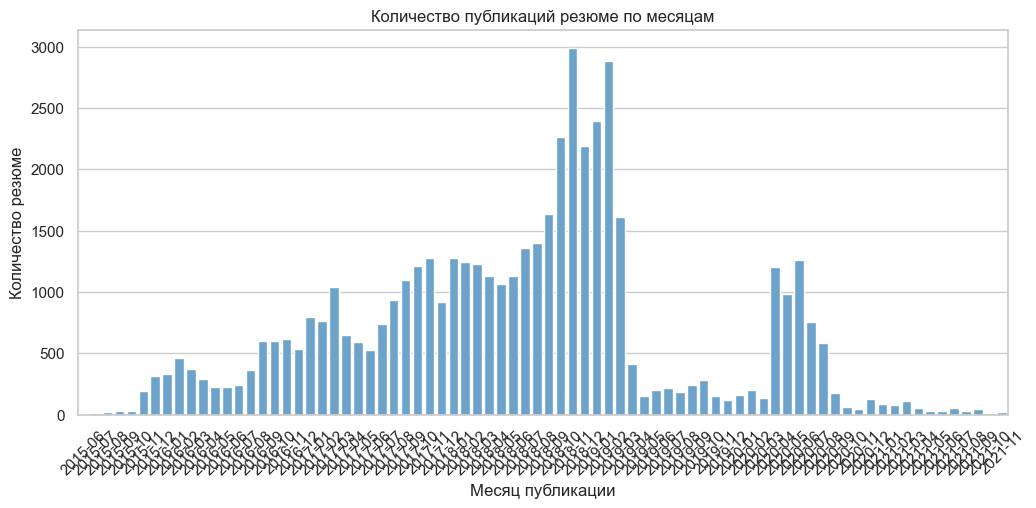

In [269]:
month_counts = time_df["publish_month"].value_counts().sort_index().reset_index()
month_counts.columns = ["publish_month", "count"]

plt.figure(figsize=(12, 5))
sns.barplot(data=month_counts, x="publish_month", y="count", color="#5DA5DA")
plt.title("Количество публикаций резюме по месяцам")
plt.xlabel("Месяц публикации")
plt.ylabel("Количество резюме")
plt.xticks(rotation=45)
plt.show()

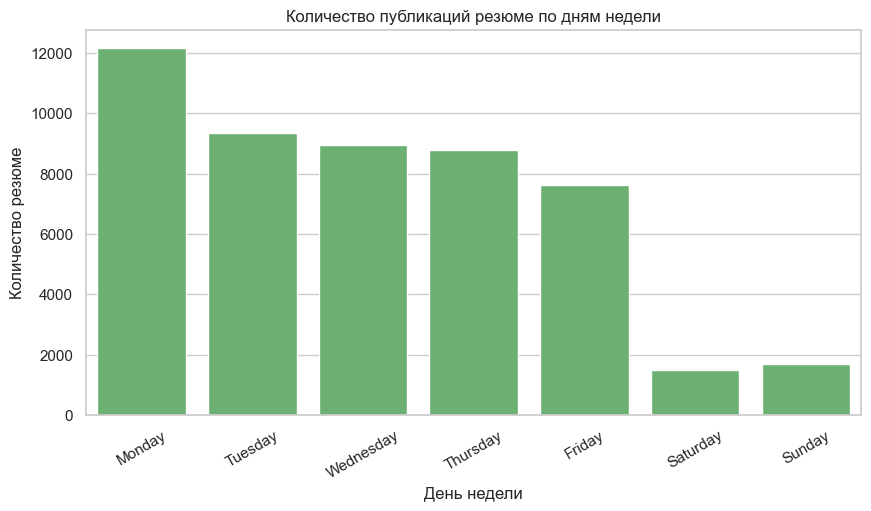

In [270]:
weekday_counts = time_df["publish_weekday"].value_counts().reindex(weekday_order).reset_index()
weekday_counts.columns = ["publish_weekday", "count"]

plt.figure(figsize=(10, 5))
sns.barplot(data=weekday_counts, x="publish_weekday", y="count", color="#60BD68")
plt.title("Количество публикаций резюме по дням недели")
plt.xlabel("День недели")
plt.ylabel("Количество резюме")
plt.xticks(rotation=30)
plt.show()

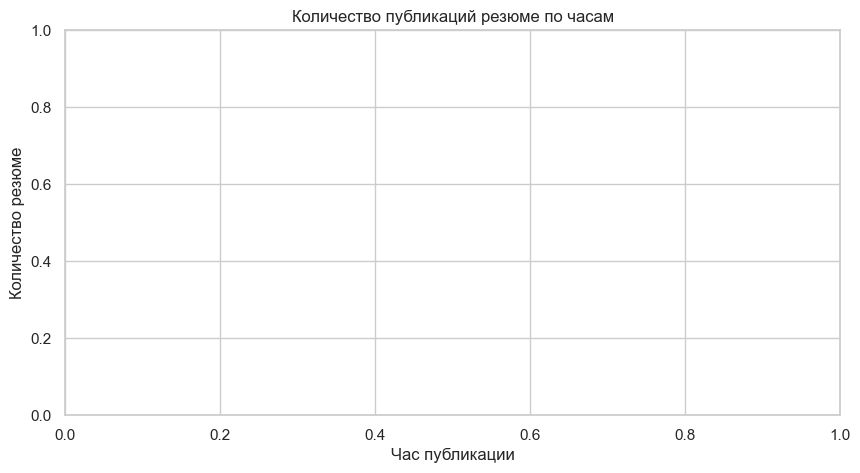

In [271]:
hour_counts = time_df["publish_hour"].value_counts().sort_index().reset_index()
hour_counts.columns = ["publish_hour", "count"]

plt.figure(figsize=(10, 5))
sns.barplot(data=hour_counts, x="publish_hour", y="count", color="#F17CB0")
plt.title("Количество публикаций резюме по часам")
plt.xlabel("Час публикации")
plt.ylabel("Количество резюме")
plt.show()

## 15. Выводы

1. `regions_extended.csv` позволяет анализировать не только конкретные регионы, но и несколько тематических тегов на один регион.
2. В ноутбуке используются два уровня анализа: `region_primary_group` как основной класс региона и `region_tag` как многотеговая аналитика.
3. Зарплатные ожидания различаются как между отдельными регионами, так и между укрупненными группами и тегами регионов.
4. Наиболее заметные факторы более высокой желаемой зарплаты: региональная принадлежность, мобильность соискателя, отрасль и опыт.
5. Следующий шаг: очистить повторы резюме и построить модель факторов зарплатных ожиданий с учетом региональных тегов.

## 16. Анализ корреляций

In [272]:
corr_df = pd.DataFrame({
    "salary": valid_salary,
    "experience": valid_experience,
    "age": age,
    "fullness_rate": fullness,
    "relocation": pd.to_numeric(df["relocation"], errors="coerce"),
    "business_trips": pd.to_numeric(df["business_trips"], errors="coerce"),
    "schedule_type_1": pd.to_numeric(df["schedule_type_1"], errors="coerce")
})

corr_matrix = corr_df.corr(method="spearman")
corr_matrix.round(3)

,salary,experience,age,fullness_rate,relocation,business_trips,schedule_type_1
salary,1.000,0.224,0.184,0.077,0.092,0.186,0.094
experience,0.224,1.000,0.408,0.513,-0.019,-0.012,-0.005
age,0.184,0.408,1.000,0.048,-0.018,0.007,0.017
fullness_rate,0.077,0.513,0.048,1.000,-0.073,-0.125,-0.036
relocation,0.092,-0.019,-0.018,-0.073,1.000,0.735,0.186
business_trips,0.186,-0.012,0.007,-0.125,0.735,1.000,0.254
schedule_type_1,0.094,-0.005,0.017,-0.036,0.186,0.254,1.000


In [273]:
salary_corr = corr_matrix[["salary"]].drop(index="salary").sort_values("salary", ascending=False)
salary_corr.round(3)

,salary
experience,0.224
business_trips,0.186
age,0.184
schedule_type_1,0.094
relocation,0.092
fullness_rate,0.077


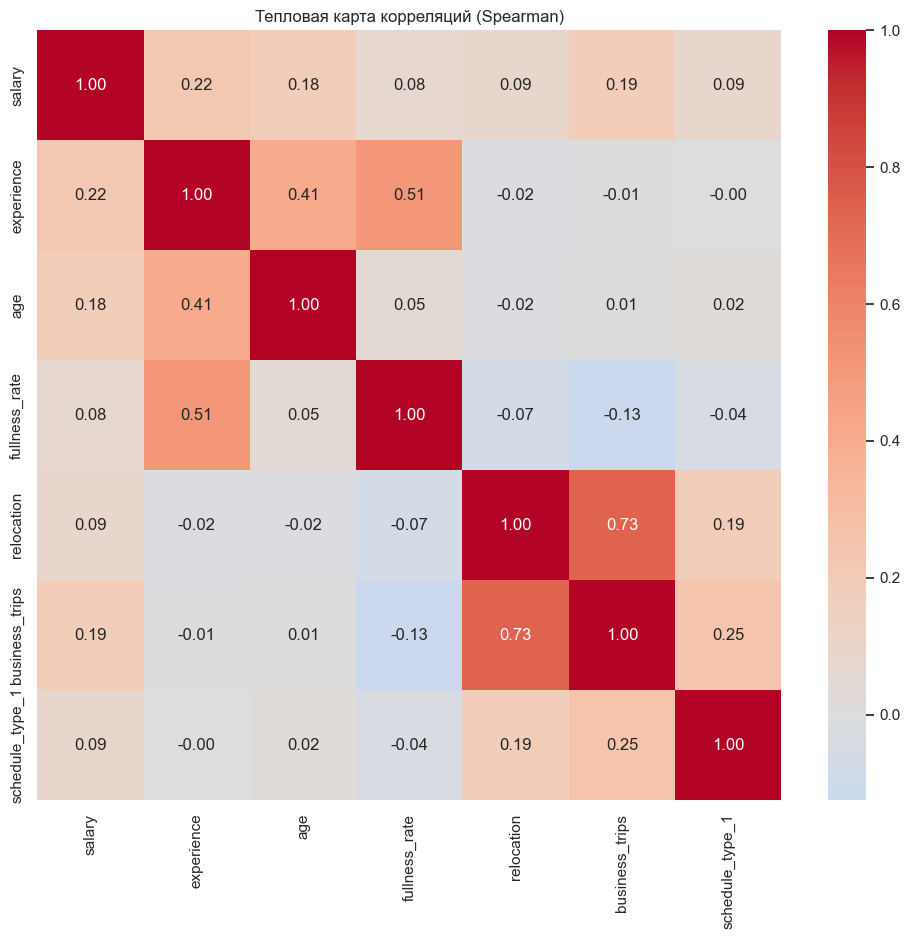

In [274]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Тепловая карта корреляций (Spearman)")
plt.show()

### Комментарий

Для разведывательного анализа здесь уместна корреляция Спирмена: она устойчивее к выбросам и лучше отражает монотонные связи в данных с тяжелыми хвостами и бинарными признаками. Интерпретировать коэффициенты стоит осторожно: корреляция не означает причинность, а многие содержательные факторы в датасете категориальные и требуют отдельного моделирования.